In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from pyprojroot import here
import torch
from torch import nn
import torch.optim
from torchinfo import summary


from collections import defaultdict

import sys
sys.path.append(str(here("Scripts")))
from model_utils import train_test_split, one_hot_encode, FPLDataPipe, Trainer


In [2]:
data_path = here("Data/FPL_data.parquet")

In [3]:
data = pd.read_parquet(data_path)
data.head()

,team_name,match_id,web_name,position,status,now_cost,player_code,penalties_order,team_code,id,gw,selected_by_percent,direct_freekicks_order,chance_of_playing_this_round,dreamteam_count,corners_and_indirect_freekicks_order,team_strength,season_id,xg_ema_4,xg_per_90_ema_4,xgot_ema_4,total_shots_ema_4,shots_on_target_ema_4,touches_opposition_box_ema_4,big_chances_missed_ema_4,xa_ema_4,xa_per_90_ema_4,expected_goal_involvements_ema_4,chances_created_ema_4,creativity_ema_4,final_third_passes_ema_4,accurate_crosses_ema_4,successful_dribbles_ema_4,accurate_passes_ema_4,recoveries_ema_4,tackles_ema_4,tackles_won_ema_4,interceptions_ema_4,blocks_ema_4,duels_won_ema_4,duels_lost_ema_4,ground_duels_won_ema_4,aerial_duels_won_ema_4,headed_clearances_ema_4,saves_ema_4,goals_prevented_ema_4,was_fouled_ema_4,high_claim_ema_4,sweeper_actions_ema_4,gk_accurate_passes_ema_4,gk_accurate_long_balls_ema_4,accurate_long_balls_ema_4,dribbled_past_ema_4,expected_goal_involvements_per_90_ema_4,expected_goals_conceded_per_90_ema_4,event_points_lagged_1,total_points_lagged_1,minutes_played_lagged_1,goals_lagged_1,assists_lagged_1,bonus_lagged_1,goals_conceded_lagged_1,team_goals_conceded_lagged_1,penalties_missed_lagged_1,penalties_scored_lagged_1,fouls_committed_lagged_1,offsides_lagged_1,start_min_lagged_1,finish_min_lagged_1,event_points
0,Brighton,24-25-prem-everton-vs-brighton-&-hove-albion,Milner,MID,a,5.0,15157,6,36,134,1,0.1,7,0,0,1,3,2425,0.0000,0.000000,0.0,0.00,0.00,0.0,0.0,0.0000,0.000000,0.000,0.00,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
1,Brighton,24-25-prem-brighton-&-hove-albion-vs-mancheste...,Milner,MID,a,5.0,15157,6,36,134,2,0.1,7,0,0,1,3,2425,0.0000,0.000000,0.0,0.00,0.00,2.0,0.0,0.1100,0.120732,0.110,3.00,43.800,2.00,2.00,0.00,28.00,0.00,4.00,2.00,0.00,2.00,4.00,2.00,4.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1.00,0.0,0.120732,0.493902,2,2,82,0,0,0,0,0,0,0,1,0,0,82,2
2,Brighton,24-25-prem-arsenal-vs-brighton-&-hove-albion,Milner,MID,d,5.0,15157,6,36,134,3,0.1,7,0,0,1,3,2425,0.0640,0.078904,0.0,0.80,0.40,2.0,0.0,0.0820,0.092165,0.190,2.20,52.760,3.60,1.60,0.40,25.60,0.80,2.80,1.20,0.40,1.20,3.60,1.60,3.60,0.0,0.0,0.0,0.0,0.40,0.0,0.0,0.0,0.0,0.60,0.0,0.225316,1.169218,2,4,73,0,0,0,0,1,0,0,1,0,0,73,1
3,Brighton,24-25-prem-tottenham-hotspur-vs-brighton-&-hov...,Milner,MID,a,5.0,15157,6,36,134,38,0.0,7,0,0,8,3,2425,0.0384,0.047342,0.0,0.48,0.24,1.2,0.0,0.0492,0.055299,0.238,1.32,58.176,2.16,0.96,0.24,16.16,0.48,1.68,0.72,0.64,0.72,2.16,1.36,2.16,0.0,0.0,0.0,0.0,0.24,0.0,0.0,0.0,0.0,0.36,0.0,0.791660,4.894472,1,5,17,0,0,0,0,0,0,0,1,0,0,17,1
4,Brighton,25-26-prem-brighton-hove-albion-vs-fulham,Milner,MID,a,4.9,15157,1,36,170,1,0.1,7,0,0,5,3,2526,0.0000,0.000000,0.0,0.00,0.00,0.0,0.0,0.0000,0.000000,0.000,0.00,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [4]:
ema_cols = [c for c in data.columns if "ema" in c]

lagged_cols = [c for c in data.columns if "lagg" in c]

id_cols = [c for c in data.columns
    if (
        ("_id" in c or "id_" in c or c == "id")
        or "code" in c
        or "name" in c
        or "position" in c
        or 'status' in c
        or data[c].dtype == 'object'
        or c == "gw"
    )
    and c not in lagged_cols
    and c not in ema_cols
    or c in ["season_id", "gw"]]

fpl_stats_cols = [c for c in data.columns if c not in ema_cols + lagged_cols + id_cols]


len(ema_cols), len(lagged_cols), len(id_cols), len(fpl_stats_cols)

(37, 14, 10, 9)

In [5]:
data.shape[1], len(ema_cols) + len(lagged_cols) + len(id_cols) +  len(fpl_stats_cols)

(70, 70)

In [6]:
X_train, y_train, X_valid, y_valid, X_test, y_test = train_test_split(data)
X_train.shape, y_train.shape

((11567, 69), (11567,))

In [7]:
[c for c in ema_cols+lagged_cols+id_cols+fpl_stats_cols if c not in X_train.columns]

['event_points']

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [9]:
id_cols

['team_name',
 'match_id',
 'web_name',
 'position',
 'status',
 'player_code',
 'team_code',
 'id',
 'gw',
 'season_id']

In [10]:
BATCH_SIZE = 256
fpl_data_pipe = FPLDataPipe(num_cols=ema_cols+lagged_cols,
                            cat_cols = ["position", "status"],
                            batch_size=BATCH_SIZE,
                            seq_length=1)

In [11]:
fpl_data_pipe.prepare_data(X_train=X_train,
                           X_valid=X_valid,
                           X_test=X_test,
                           y_train=y_train,
                           y_valid=y_valid,
                           y_test=y_test)

In [12]:
train_dataloader, valid_dataloader, test_dataloader = fpl_data_pipe.get_dataloaders()

In [13]:
x, y = next(iter(train_dataloader))
x.shape, y.shape

(torch.Size([256, 1, 61]), torch.Size([256, 1]))

In [14]:
class MLP(nn.Module):
    def __init__(self, input_size: int,
                 hidden_size1: int,
                 hidden_size2: int,
                 output_size: int):
        super(MLP, self).__init__()

        block1 = nn.Sequential(
            nn.Linear(input_size, hidden_size1),
            nn.LeakyReLU(.01),
            nn.BatchNorm1d(hidden_size1),
            nn.Dropout(0.3)
        )
        block2 = nn.Sequential(
            nn.Linear(hidden_size1, hidden_size2),
            nn.LeakyReLU(.01),
            nn.BatchNorm1d(hidden_size2),
            nn.Dropout(0.2)
        )
        block3 = nn.Sequential(
            nn.Linear(hidden_size2, output_size)
        )

        self.block_stack = nn.Sequential(
            block1,
            block2,
            block3
        )

    def forward(self, x):
        return self.block_stack(x)

In [15]:
class RNN(nn.Module):
    def __init__(self, input_size: int,
                 hidden_size: int,
                 num_layers: int,
                 output_size: int):
        super(RNN, self).__init__()

        self.rnn = nn.RNN(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        rnn_out, _ = self.rnn(x)
        last_hidden_state = rnn_out[:, -1, :]
        output = self.fc(last_hidden_state)
        return output

In [16]:
mlp = MLP(
    input_size=x.shape[1] * x.shape[2],
    hidden_size1=64,
    hidden_size2=16,
    output_size=1
).to(device)


rnn = RNN(
    input_size=x.shape[2],
    hidden_size=32,
    num_layers=2,
    output_size=1
).to(device)

In [17]:
"""summary(
    model=mlp,
    input_size=(BATCH_SIZE, x.shape[1]),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=18

)"""

'summary(\n    model=mlp,\n    input_size=(BATCH_SIZE, x.shape[1]),\n    col_names=["input_size", "output_size", "num_params", "trainable"],\n    col_width=18\n\n)'

In [18]:
learning_rate = 0.001
weight_decay = .005
loss_fn = nn.HuberLoss(delta=1.0)


In [19]:
trainer = Trainer(device=device,
                  random_state=77)

In [20]:
model = [mlp, rnn]
model_names = ["mlp", "rnn"]
NUM_EPOCHS = 400
results = {}
for m, name in zip(model, model_names):
    optimizer = torch.optim.AdamW(lr=learning_rate,
                            params=m.parameters(),
                            weight_decay=weight_decay)
    print("MODEL:", name)
    results[name] = trainer.model_eval(train_dataloader=train_dataloader,
                             valid_dataloader=valid_dataloader,
                             model=m,
                             num_epochs=NUM_EPOCHS,
                             optimizer=optimizer,
                             loss_fn=loss_fn,
                             tolerance=0.0001,
                             patience=100)


MODEL: mlp


  0%|          | 0/400 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 2.2518 | Valid Loss: 2.2569
Train MSE: 15.8583 | Valid MSE: 16.7964
Train MAE: 2.7151 | Valid MAE : 2.7639
Train R2: -0.7800 | Valid R2 : -0.7882
Epoch: 40 | Train Loss: 1.3770 | Valid Loss: 1.5367
Train MSE: 8.9526 | Valid MSE: 10.7696
Train MAE: 1.7664 | Valid MAE : 1.9803
Train R2: -0.0049 | Valid R2 : -0.1465
Epoch: 80 | Train Loss: 1.3182 | Valid Loss: 1.5494
Train MSE: 8.3846 | Valid MSE: 10.7608
Train MAE: 1.7093 | Valid MAE : 1.9961
Train R2: 0.0589 | Valid R2 : -0.1456
Epoch: 120 | Train Loss: 1.2865 | Valid Loss: 1.5628
Train MSE: 8.0967 | Valid MSE: 10.7654
Train MAE: 1.6756 | Valid MAE : 2.0075
Train R2: 0.0912 | Valid R2 : -0.1461
Early stopping | No improvement since 100 epochs
MODEL: rnn


  0%|          | 0/400 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 1.7510 | Valid Loss: 1.5433
Train MSE: 12.4296 | Valid MSE: 10.4544
Train MAE: 2.1654 | Valid MAE : 1.9961
Train R2: -0.3951 | Valid R2 : -0.1130
Epoch: 40 | Train Loss: 1.3655 | Valid Loss: 1.5363
Train MSE: 8.9880 | Valid MSE: 10.6786
Train MAE: 1.7554 | Valid MAE : 1.9793
Train R2: -0.0088 | Valid R2 : -0.1368
Epoch: 80 | Train Loss: 1.3388 | Valid Loss: 1.5559
Train MSE: 8.6262 | Valid MSE: 10.3803
Train MAE: 1.7269 | Valid MAE : 2.0109
Train R2: 0.0318 | Valid R2 : -0.1051
Early stopping | No improvement since 100 epochs


In [21]:
"""
results = trainer.model_eval(train_dataloader=train_dataloader,
                             test_dataloader=valid_dataloader,
                             model=mlp,
                             num_epochs=NUM_EPOCHS,
                             optimizer=optimizer,
                             loss_fn=loss_fn,
                             tolerance=0.001,
                             patience=NUM_EPOCHS // 20)"""

'\nresults = trainer.model_eval(train_dataloader=train_dataloader,\n                             test_dataloader=valid_dataloader,\n                             model=mlp,\n                             num_epochs=NUM_EPOCHS,\n                             optimizer=optimizer,\n                             loss_fn=loss_fn,\n                             tolerance=0.001,\n                             patience=NUM_EPOCHS // 20)'

In [22]:
results_frame = pd.DataFrame(results)
results_frame.tail()

,mlp,rnn
valid_mse,"[16.796436309814453, 16.074726104736328, 15.00...","[10.454366683959961, 10.600728988647461, 10.69..."
train_mae,"[2.715074300765991, 2.571580648422241, 2.41122...","[2.165391206741333, 1.8115086555480957, 1.7943..."
valid_mae,"[2.7639000415802, 2.6515939235687256, 2.491200...","[1.9960912466049194, 1.9783968925476074, 1.973..."
train_r2,"[-0.7799872159957886, -0.6862895488739014, -0....","[-0.3951345682144165, -0.04805493354797363, -0..."
valid_r2,"[-0.7881630659103394, -0.7113292217254639, -0....","[-0.11298084259033203, -0.1285628080368042, -0..."


KeyError: "None of [Index(['train_loss', 'test_loss'], dtype='str')] are in the [columns]"

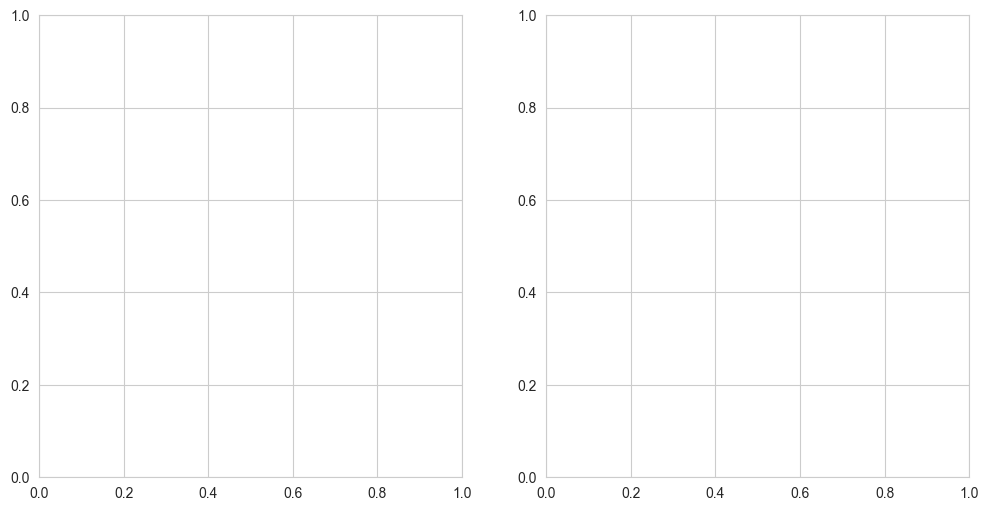

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
sns.lineplot(results_frame[["train_loss", "test_loss"]],
             palette=["tomato", "steelblue"],
             ax=ax[0])
sns.lineplot(results_frame[["train_mae", "test_mae"]],
             palette=["tomato", "steelblue"],
             ax=ax[1])
fig.suptitle("MLP - Porównanie straty w trakcie treningu", fontsize=16);
plt.tight_layout()


In [ ]:
test_results = defaultdict(list)

test_results["test_loss"].append(trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[0])
test_results["test_mse"].append(trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[1])
test_results["test_mae"].append(trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[2])
test_results["test_r2"].append(trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[3])

y_pred = trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[4]

In [ ]:
y_pred.shape, y_test.shape

In [ ]:
preds = pd.DataFrame({
    "name" : data.loc[y_test.index, "web_name"],
    "y_true": y_test.values,
    "y_pred": y_pred.numpy().flatten()
})

In [ ]:
preds.y_pred.max(), preds.y_true.max()

In [ ]:
players = data.loc[y_test.index, "web_name"].sample(4, random_state=2790)
players

In [ ]:
plt.figure(figsize=(12, 6))
fig, ax = plt.subplots(nrows=2, ncols=len(players) // 2, figsize=(12, 6))
for i, player in enumerate(players):
    sns.scatterplot(data=preds.loc[preds.name==player, ["y_pred", "y_true"]].reset_index(drop=True),
                    palette=["tomato", "steelblue"], ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(player)
plt.suptitle("MLP - Predykcje vs rzeczywiste punkty", fontsize=16)
plt.tight_layout();
